In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import mplfinance as mpf
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 행(row) 다 보기
pd.set_option('display.max_rows', None)

# 열(column) 다 보기
pd.set_option('display.max_columns', None)

In [2]:
def get_stock_data(ticker, period="5y", my_price=0):
    etf = yf.Ticker(ticker)
    df = etf.history(period, interval="1d")
    df.index = df.index.tz_localize(None)

    if df.empty:
        return None, None, None

    df_w = df.resample('W').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    })

    df_m = df.resample('ME').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    })

    if my_price > 0:
        df['MY_PRICE'] = my_price
        df_w['MY_PRICE'] = my_price
        df_m['MY_PRICE'] = my_price

    df['MA20'] = df['Close'].rolling(20).mean()
    df['MA60'] = df['Close'].rolling(60).mean()
    df['MA120'] = df['Close'].rolling(120).mean()
    df['MA240'] = df['Close'].rolling(240).mean()

    df_w['MA10'] = df_w['Close'].rolling(10).mean()
    df_w['MA20'] = df_w['Close'].rolling(20).mean()

    df_m['MA10'] = df_m['Close'].rolling(10).mean()

    df = df.dropna()
    df_w = df_w.dropna()
    df_m = df_m.dropna()

    return df, df_w, df_m

In [3]:
def draw_chart(ticker_nm, df_d, df_w, df_m):
    fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(22, 54))
    mc = mpf.make_marketcolors(
        up='red',
        down='blue',
        inherit=True
    )
    style = mpf.make_mpf_style(marketcolors=mc)
    fig.suptitle(f"{ticker_nm}", fontsize=50, fontweight='bold', y=0.97)
    fig.subplots_adjust(
        hspace=0.3,   # 👈 차트 사이 간격
        top=0.93      # 👈 전체 제목 공간 확보
    )

    mpf.plot(
        df_m,
        type='candle',
        ax=axes[0],
        volume=axes[1],
        addplot=[mpf.make_addplot(df_m['MA10'], label='MA10', ax=axes[0])],
        style=style,
        returnfig=True,
        datetime_format='%Y-%m',
        show_nontrading=True
    )
    axes[0].set_title(f'{ticker_nm}_Monthly', fontsize=14, fontweight='bold', pad=10)

    df_wr = df_w.tail(52) ## 1년
    adps = [
        mpf.make_addplot(df_wr['MA10'], label='MA10', width=1.3, alpha=1, ax=axes[2]),
        mpf.make_addplot(df_wr['MA20'], label='MA20', width=1.3, alpha=1, ax=axes[2])
    ]
    mpf.plot(
        df_wr,
        type='candle',
        ax=axes[2],
        volume=axes[3],
        addplot=adps,
        style=style,
        returnfig=True,
        datetime_format='%Y-%m',
        show_nontrading=True
    )
    axes[2].set_title(f'{ticker_nm}_Weekly', fontsize=14, fontweight='bold', pad=10)

    df_dr = df_d.tail(90) ## 3개월
    adps = [
        mpf.make_addplot(df_dr['MA20'], label='MA20', width=1.3, alpha=1, ax=axes[4]),
        mpf.make_addplot(df_dr['MA60'], label='MA60', width=1.3, alpha=1, ax=axes[4]),
        mpf.make_addplot(df_dr['MA120'], label='MA120', width=1.3, alpha=1, ax=axes[4]),
        mpf.make_addplot(df_dr['MA240'], label='MA240', width=1.3, alpha=1, ax=axes[4])
    ]

    mpf.plot(
        df_dr,
        type='candle',
        ax=axes[4],
        volume=axes[5],
        addplot=adps,
        style=style,
        returnfig=True,
        show_nontrading=True
    )
    axes[4].set_title(f'{ticker_nm}_Daily', fontsize=14, fontweight='bold', pad=10)
    ##plt.axhline(color='blue', linestyle='--', linewidth=1)


    plt.show()


분석 결과
- 매도
    + 빅테크 50% 매도, S&P500 20% 매도, 나스닥 매도
- 관망
    + 반도체
    + 금
    + KODEX미국채혼합, 미국채10년
- 매수
    + 은행
    + 다우존스 (MA10 이평선 근접 시 매수) 현재 과열 중
    + AI인프라

클로이드 내 의견 동의
보충의견
매수 — 조건부 동의해요 🔼
은행 → 다만 일봉 MA20 꺾임 있으니 거래량 확인 후 진입 권장
다우존스 → MA10 근접 시 매수 조건 정확해요. 지금 과열 인식하고 기다리는 판단이 좋아요
AI인프라 → 셋 중 가장 차트 양호. 거래량 터지는 양봉 확인 후 진입이면 더 안전


---

#### S&P500
- 나스닥과 유사함. 차이점은 MA20이 아직 MA120을 뚫지 않았다는 점..
- S&P500이 나스닥을 후행하는 패턴은 꽤 일반적이에요. 나스닥이 기술주 중심이라 변동성이 먼저 반응하고, S&P500이 뒤따라가는 구조거든요.
- 평단가가 낮아 매수/매도 전략 권유
    + 1단계: 지금 절반 매도 → 수익 일부 확정
    + 2단계: 주봉 데드크로스 심화 또는 월봉 MA10 근접 시 나머지 매도
    + 3단계: 재진입은 월봉 MA10 회복 확인 후

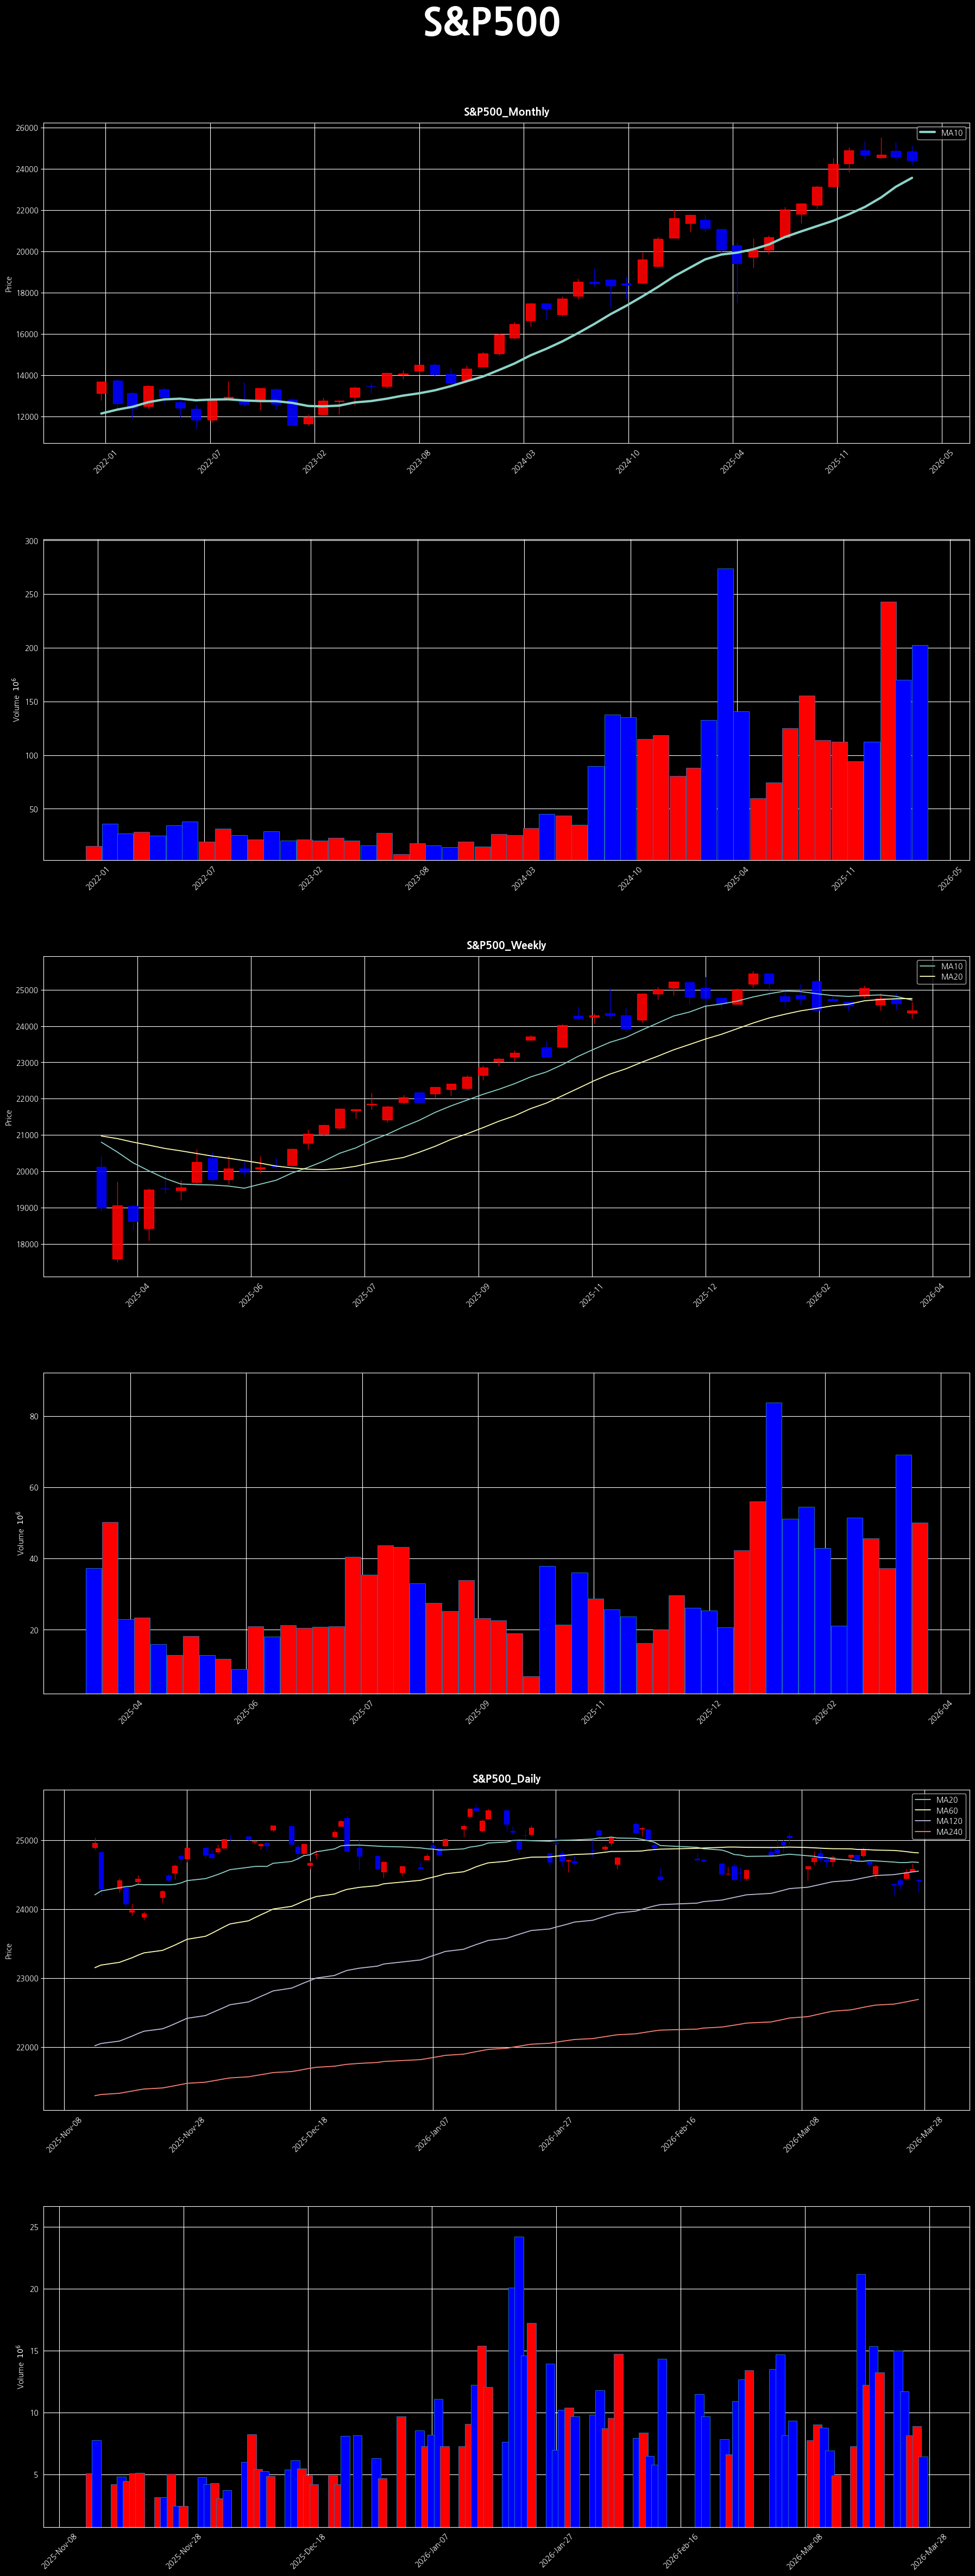

In [4]:
# dict_tickers = {"360750.KS":"S&P500",  "446720.KS":"미국배당다우존스", "133690.KS":"미국나스닥100",
#                 "294400.KS":"키움200TR", "195980.KS":"MSCI", "466940.KS":"은행고배당Top10",
#                 "272580.KS":"단기채권", "284430.KS":"KODEX미국채혼합", "490490.KS":"미국배당미국채혼합",
#                 "148070.KS":"한국채10년", "305080.KS":"미국채10년", "0111P0.KS":"나스닥50미채권50", "465580.KS":"미국빅테크TOP7", "446770.KS":"글로벌반도체TOP4",
#                 "352560.KS":"US리츠", "411060.KS":"금", "456610.KS":"미국달러SOFR", "487230.KS":"미국AI전력인프라", "0048K0.KS":'차이나휴먼로봇', "466920.KS":"조선top3" }


df, df_w, df_m = get_stock_data('360750.KS', period="5y")
draw_chart('S&P500', df, df_w, df_m)


### 나스닥
- 전형적인 역배열 (MA60 > MA120 > MA20)
- 가장 민감하게 반응하기 때문에 하락 시 가장 먼저 내려, MA60은 중간, MA120은 느리게 반응
- 매수관점
    + 1단계 : MA20 이 MA120 돌파 -> 단기 회복 신호
    + 2단계 : MA20 이 MA60 돌파 -> 중기 회복 신호
    + 3단계 : 완전 회복 신호 -> 진입 확신 구간
        +

- 의사결정
    + **지금 매도 → 월봉 MA10 이탈 확인 시**
    + **재진입은 월봉 캔들이 MA10 위로 회복될 때**

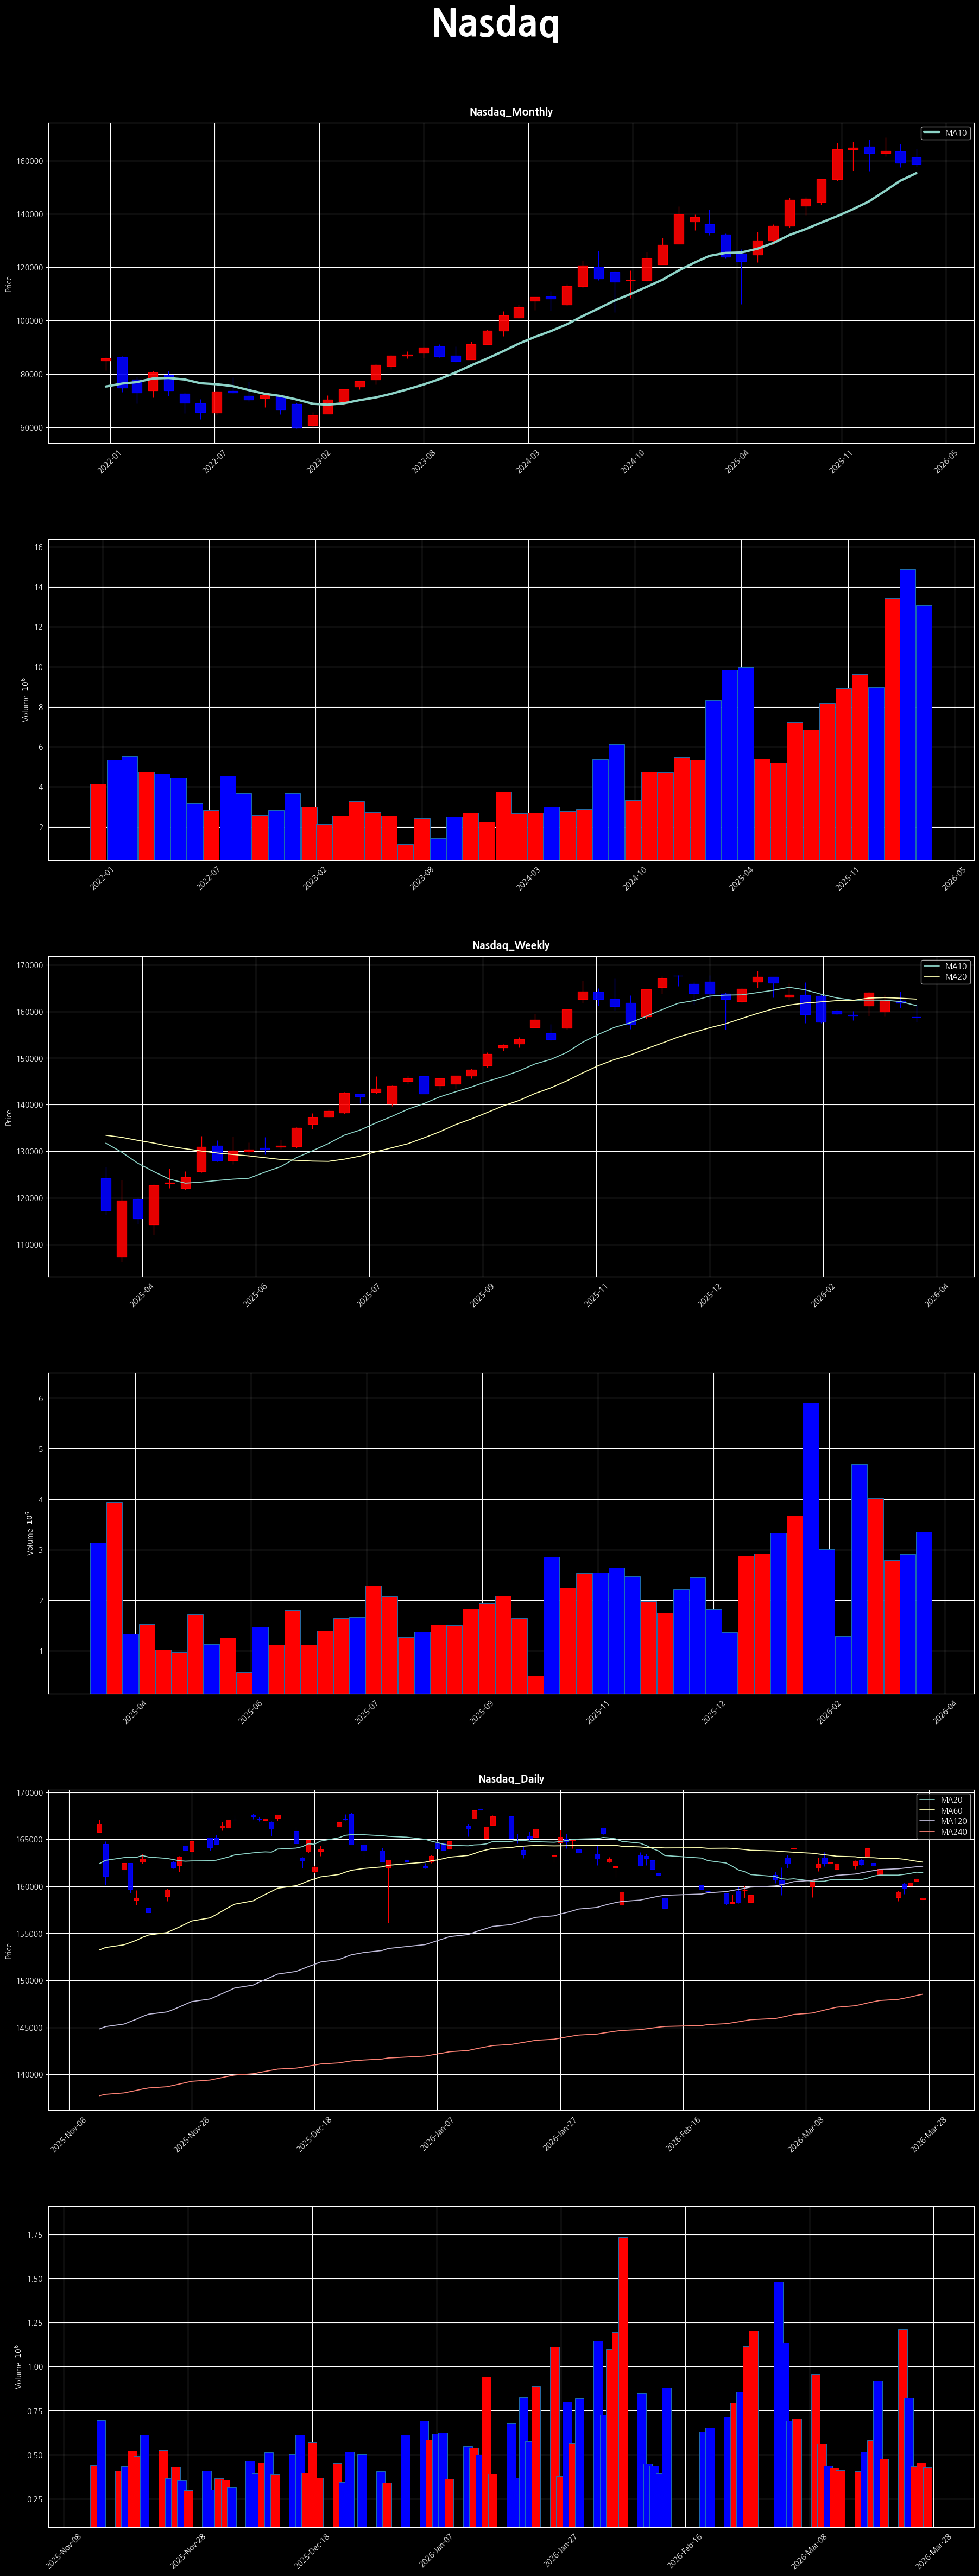

In [5]:
df, df_w, df_m = get_stock_data('133690.KS', period="5y")
draw_chart('Nasdaq', df, df_w, df_m)

### 뱅크
#### 일별 시나리오별 대응 (상황 해석 대응)
- 상황 | 해석 | 대응
    - MA20↓ MA60 교차, MA60도 꺾임 | 추세 전환 가능성 높음 | 비중 축소 or 관망
    - MA20↓ MA60 교차, MA60은 유지 | 단기 조정 후 재상승 가능 | 손절선 명확히 하고 홀딩
    - 교차 후 다시 MA20이 MA60 위로 | 골든크로스 회복 | 추가매수 신호


중장기 (월봉/주봉)

추세 살아있음 ✅
섣불리 손절할 구간 아님 ✅

단기 (일봉)

거래량 부재 ⚠️
MA20 하향 전환 ⚠️
MA60 교차 임박 가능성 ⚠️

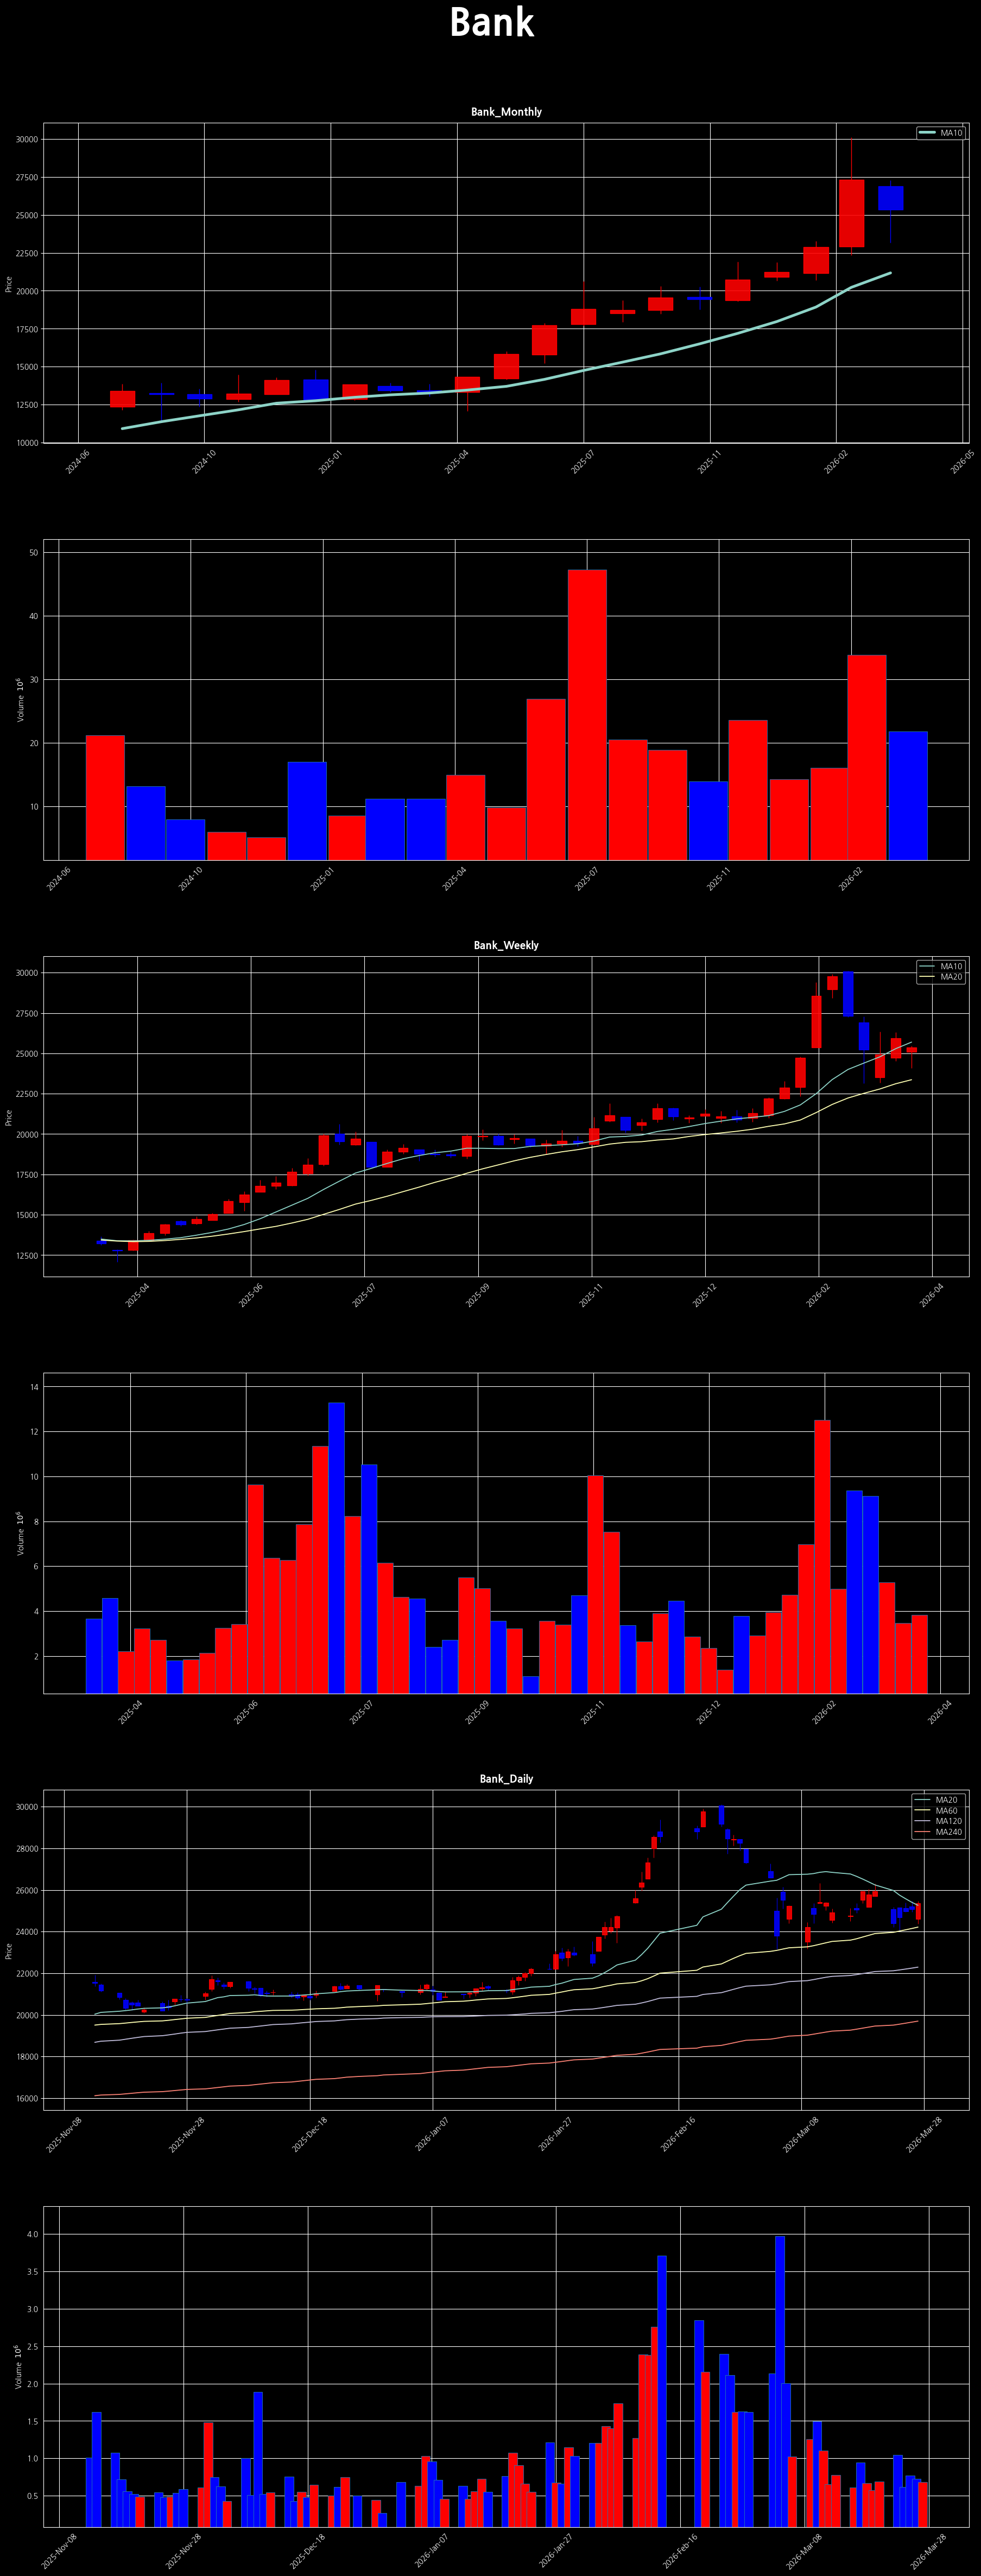

In [6]:
df, df_w, df_m = get_stock_data('466940.KS', period="5y")
draw_chart('Bank', df, df_w, df_m)

### 금 (관망)
⚠️ 주봉이 핵심 변수
말씀하신 대로 주봉에서 캔들이 MA10, MA20 아래로 내려왔어요. 이게 꽤 중요한 포인트인데

- 1월 고점(~37,500) 대비 현재 약 20% 조정
- 주봉 MA10, MA20이 아직 우상향이긴 하나 가격이 선 아래에 있다는 건 단기 모멘텀 약화 신호
- 2주 연속 음봉이 추가로 이어지면 주봉 MA선들 자체가 꺾일 가능성

✅ 그나마 긍정적인 것

- 말씀하신 대로 최근 거래량이 고점 대비 크지 않아요 → 대규모 매도 패닉은 아닌 상태
- 일봉 MA240(장기선)은 아직 25,000 부근으로 한참 아래 → 장기 지지대 두텁게 살아있음
- 월봉 캔들이 MA10 위에서 형성 중 → 장기 추세 훼손 아님

매수 재진입 트리거는 주봉 캔들이 MA10 위로 회복되는 것 확인 후가 가장 안전해 보입니다.
지금은 추가매수보다 주봉 지지 회복 확인이 우선이에요.

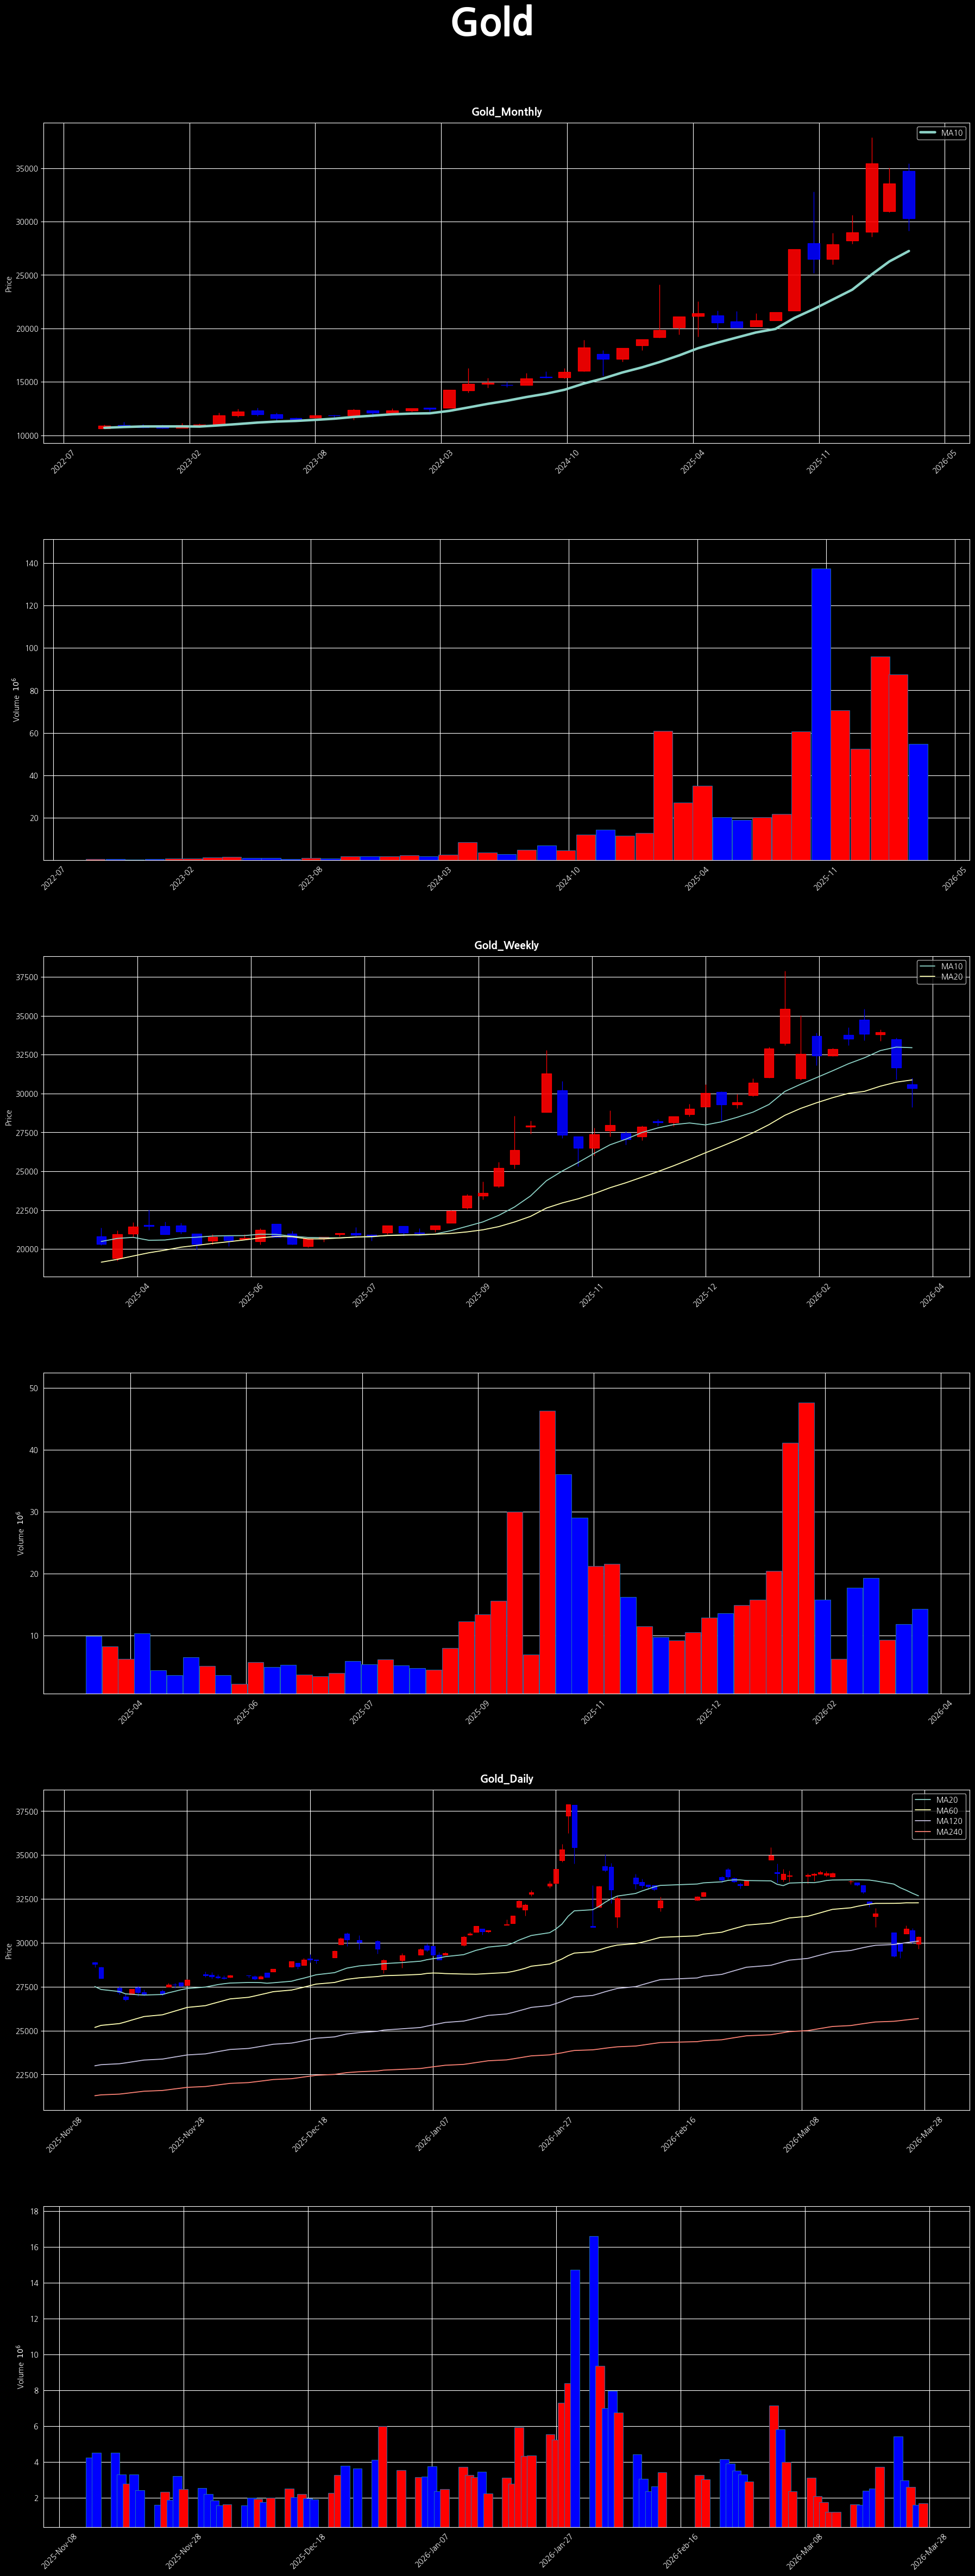

In [7]:
df, df_w, df_m = get_stock_data('411060.KS', period="5y")
draw_chart('Gold', df, df_w, df_m)

### AI 전력 인프라
추가 포인트
일봉에서 중요한 것

- MA60, MA120이 수렴(겹침)되어 있다는 건 방향성을 탐색 중이라는 의미예요
- 이 수렴 후 어느 방향으로 벌어지느냐가 단기 추세를 결정해요
- 현재 캔들이 MA60/120 위에서 형성되고 있다면 위로 벌어질 가능성이 있어요

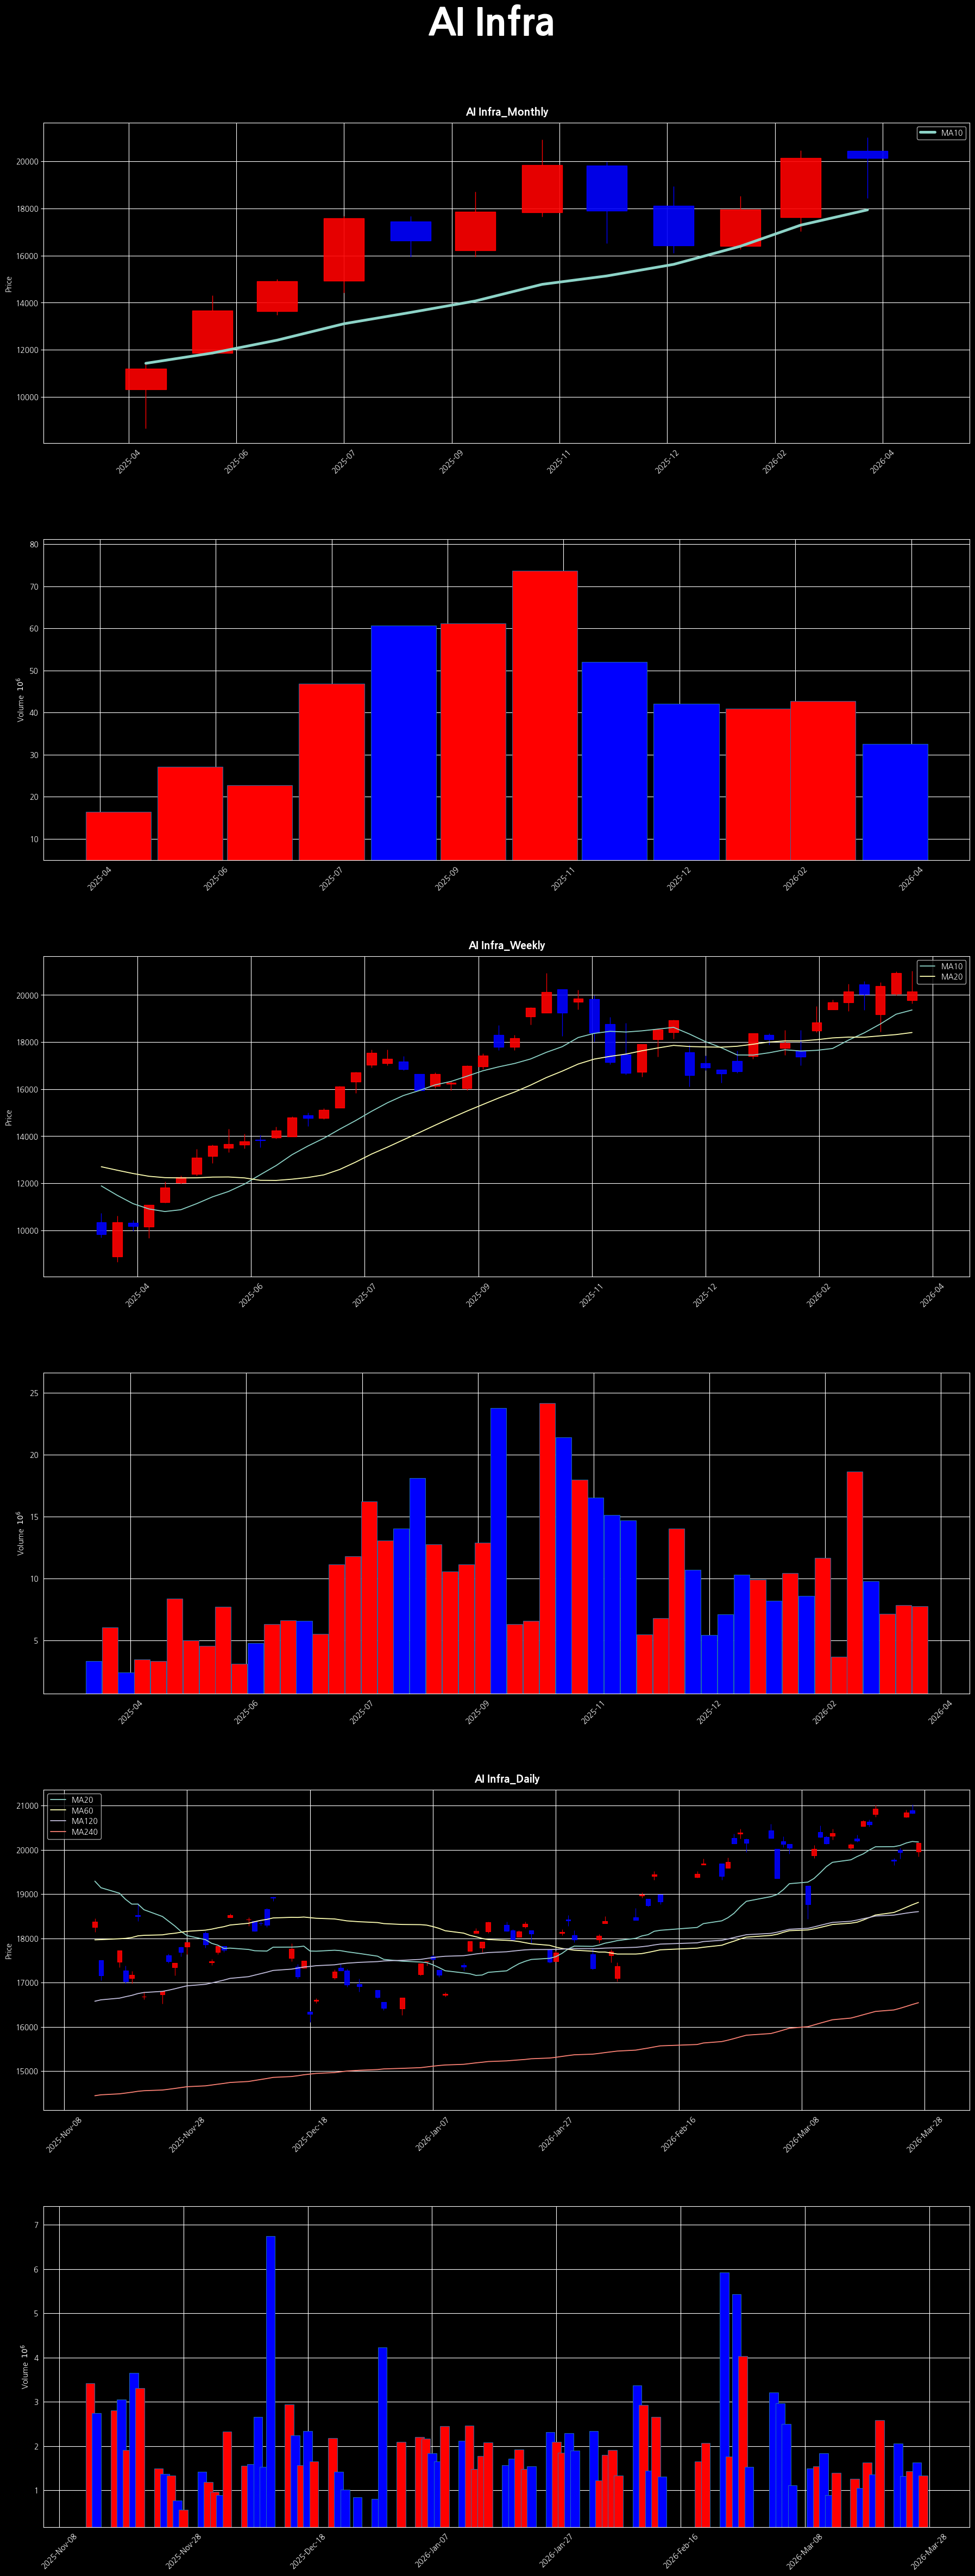

In [8]:
df, df_w, df_m = get_stock_data('487230.KS', period="5y")
draw_chart('AI Infra', df, df_w, df_m)

### 다우존스
굳이 주의할 점 하나
일봉에서 MA20과 캔들 사이 간격이 꽤 벌어져 있어요. 즉 단기 과열 가능성이 있어서 지금 당장 풀베팅보다는

현재가 분할 진입 1차
단기 눌림(MA20 근처 조정) 시 2차 추가매수

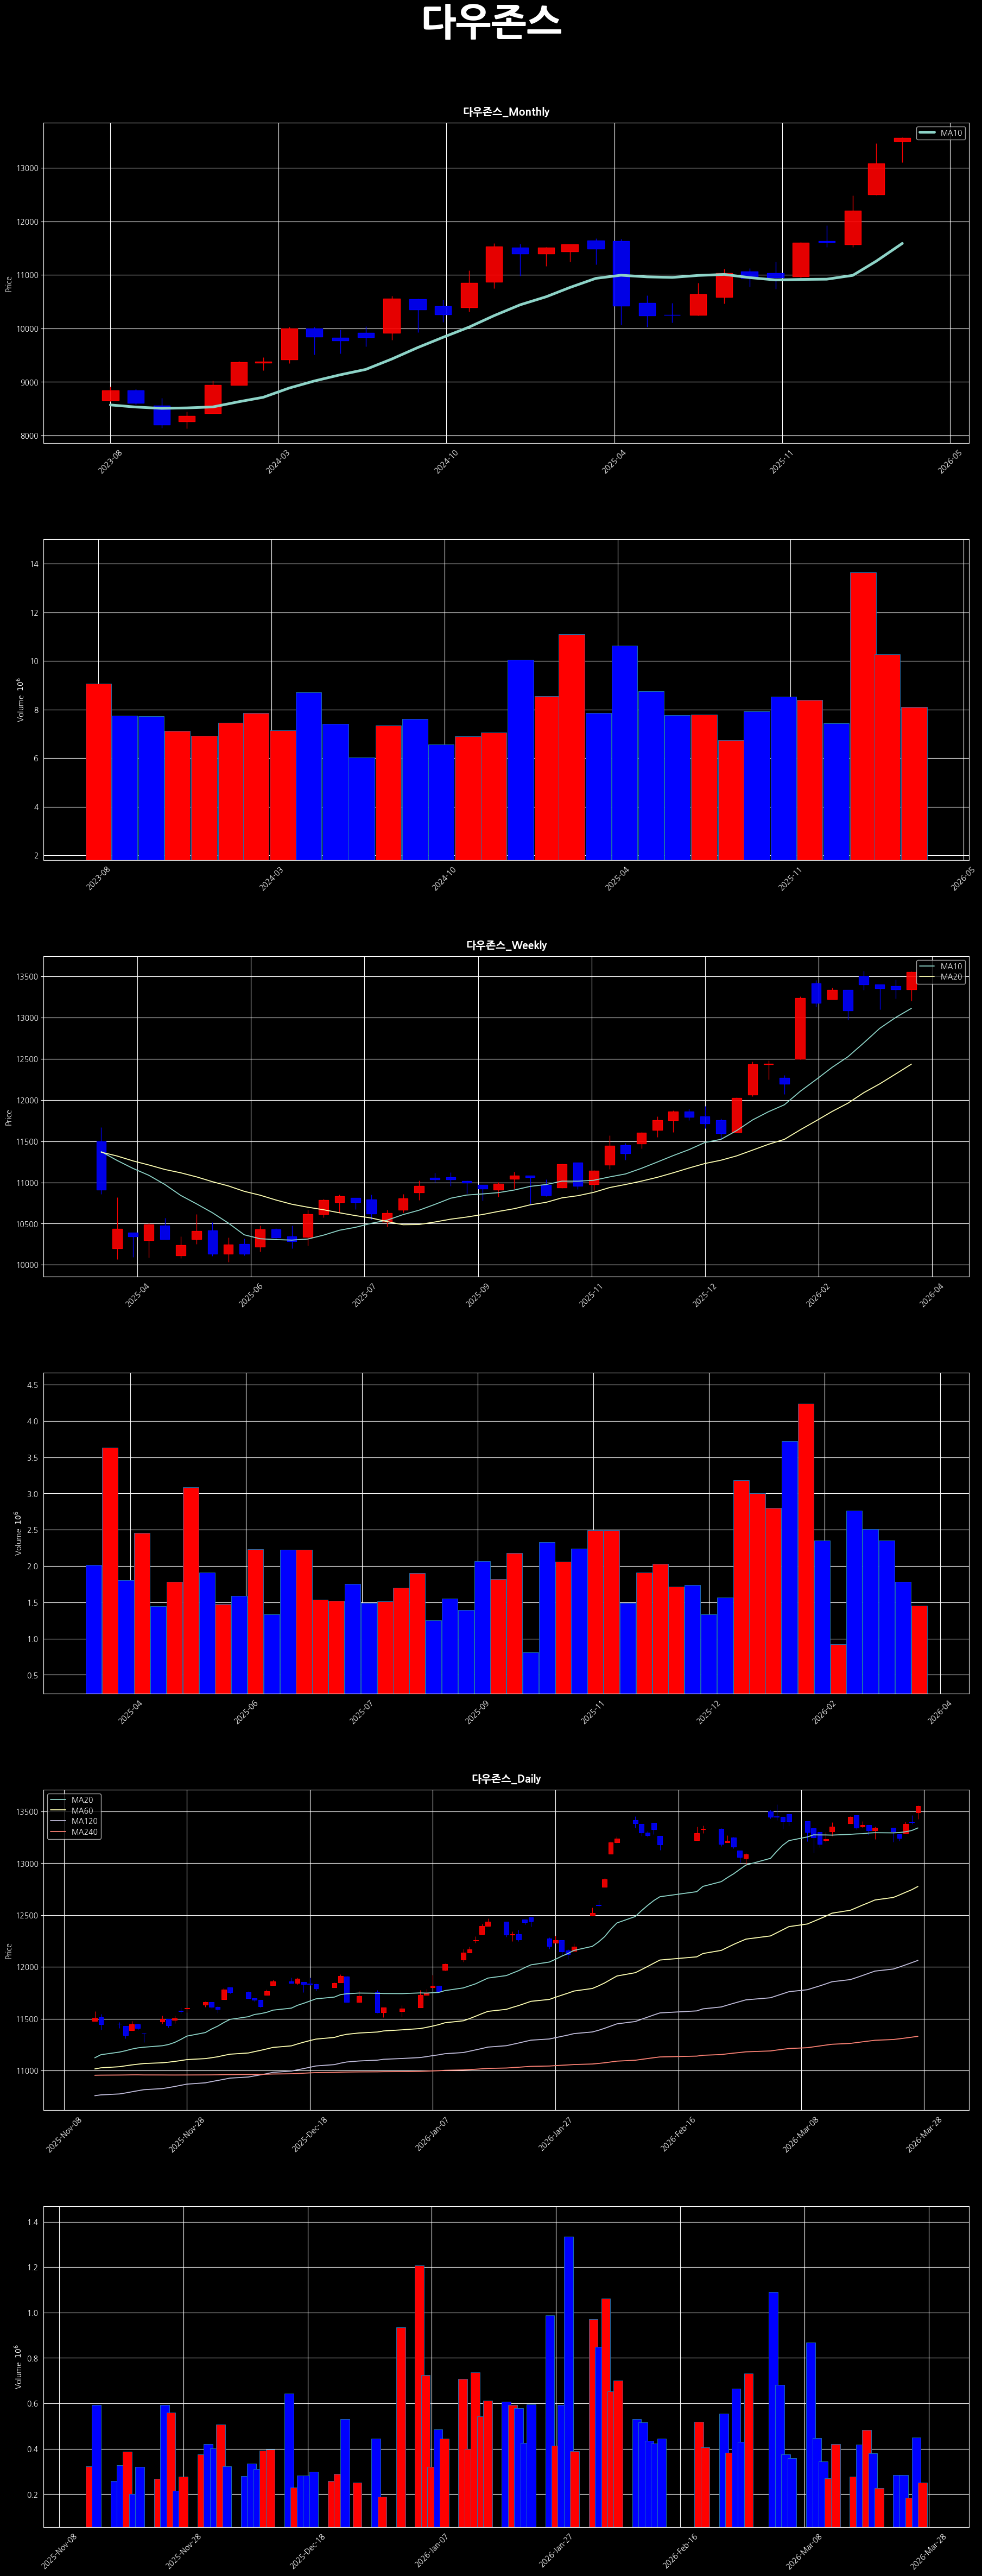

In [9]:
df, df_w, df_m = get_stock_data('446720.KS', period="5y")
draw_chart('다우존스', df, df_w, df_m)

### KODEX미국채혼합
- 지금 당장 진입보다 MA20 회복 확인 후 진입이 훨씬 좋은 전략이에요.
- 눌림목을 기다리는 당신의 직관이 맞습니다. 오늘 본 5개 종목 중에서 중장기 안정성은 가장 높은 편이에요.

"MA20 근처에서 사는게 좋은가"에 대한 견해
결론부터 말하면 맞는 전략이에요. 이유는

- 지금은 강한 상승 추세에서의 자연스러운 눌림목 구간
- 이런 차트에서 MA20은 전통적인 1차 지지선이자 매수 타이밍
- 주봉 MA10 터치 후 반등하는 패턴이 나오면 더 강한 진입 신호

구분 | 가격대 | 비중
- 1차 매수 | 일봉 MA20 회복 확인 시 | 40%
- 2차 매수 | 주봉 MA10 터치 후 반등 시 | 40%
- 예비 | 일봉 MA60 지지 확인 시 | 20%

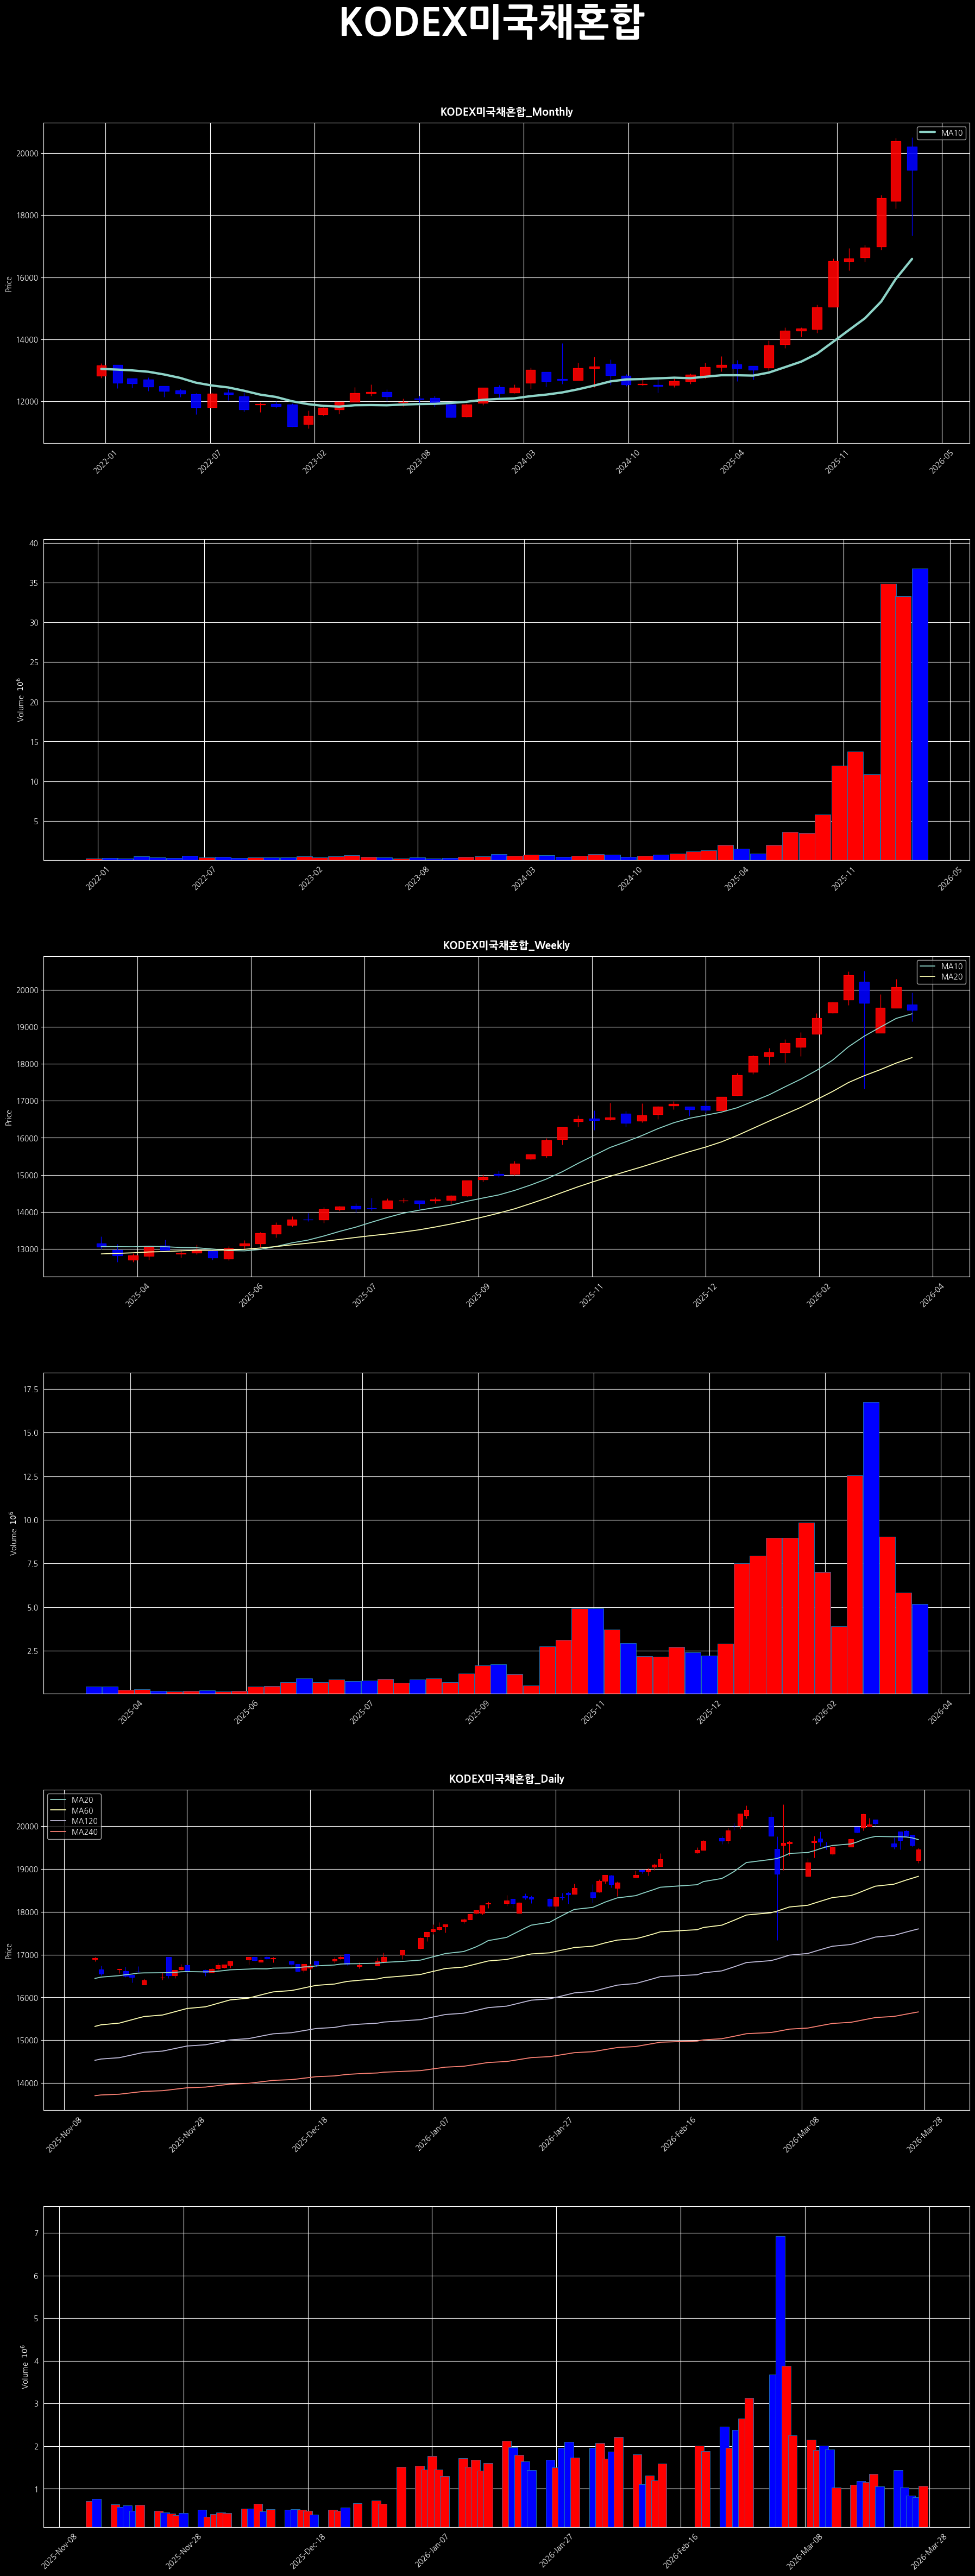

In [10]:
df, df_w, df_m = get_stock_data('284430.KS', period="5y")
draw_chart('KODEX미국채혼합', df, df_w, df_m)

### 미국채 10년
주봉 MA10 반등이 중요한 이유
이런 패턴은 꽤 의미 있어요
- MA10 꺾임 → MA20 근접 → MA10 재반등
- 이게 추세 재확인 신호로 자주 나타나는 패턴이에요. 단순 눌림 후 재상승 가능성이 높아요.

조심할 부분 하나
- 일봉 MA60이 횡보한다는 건 중기 방향성이 아직 미확정이라는 뜻이에요. MA60이 우상향으로 전환되는 걸 확인하면 신뢰도가 훨씬 높아져요.

**매크로 (주의할 점)**
- **전쟁 + 인플레이션 동시발생하면 채권이 불리**
- **전쟁 + 경기침체 동시발생하면 채권이 유리**

인플레이션 완화 신호
→ 금리 인하 기대감 상승
→ 채권 가격 상승 ✅
→ 미국채10년 매수 타이밍

전쟁 장기화
→ 재정지출 확대 (국방비, 재건비용)
→ 국채 발행 증가
→ 채권 공급 과잉

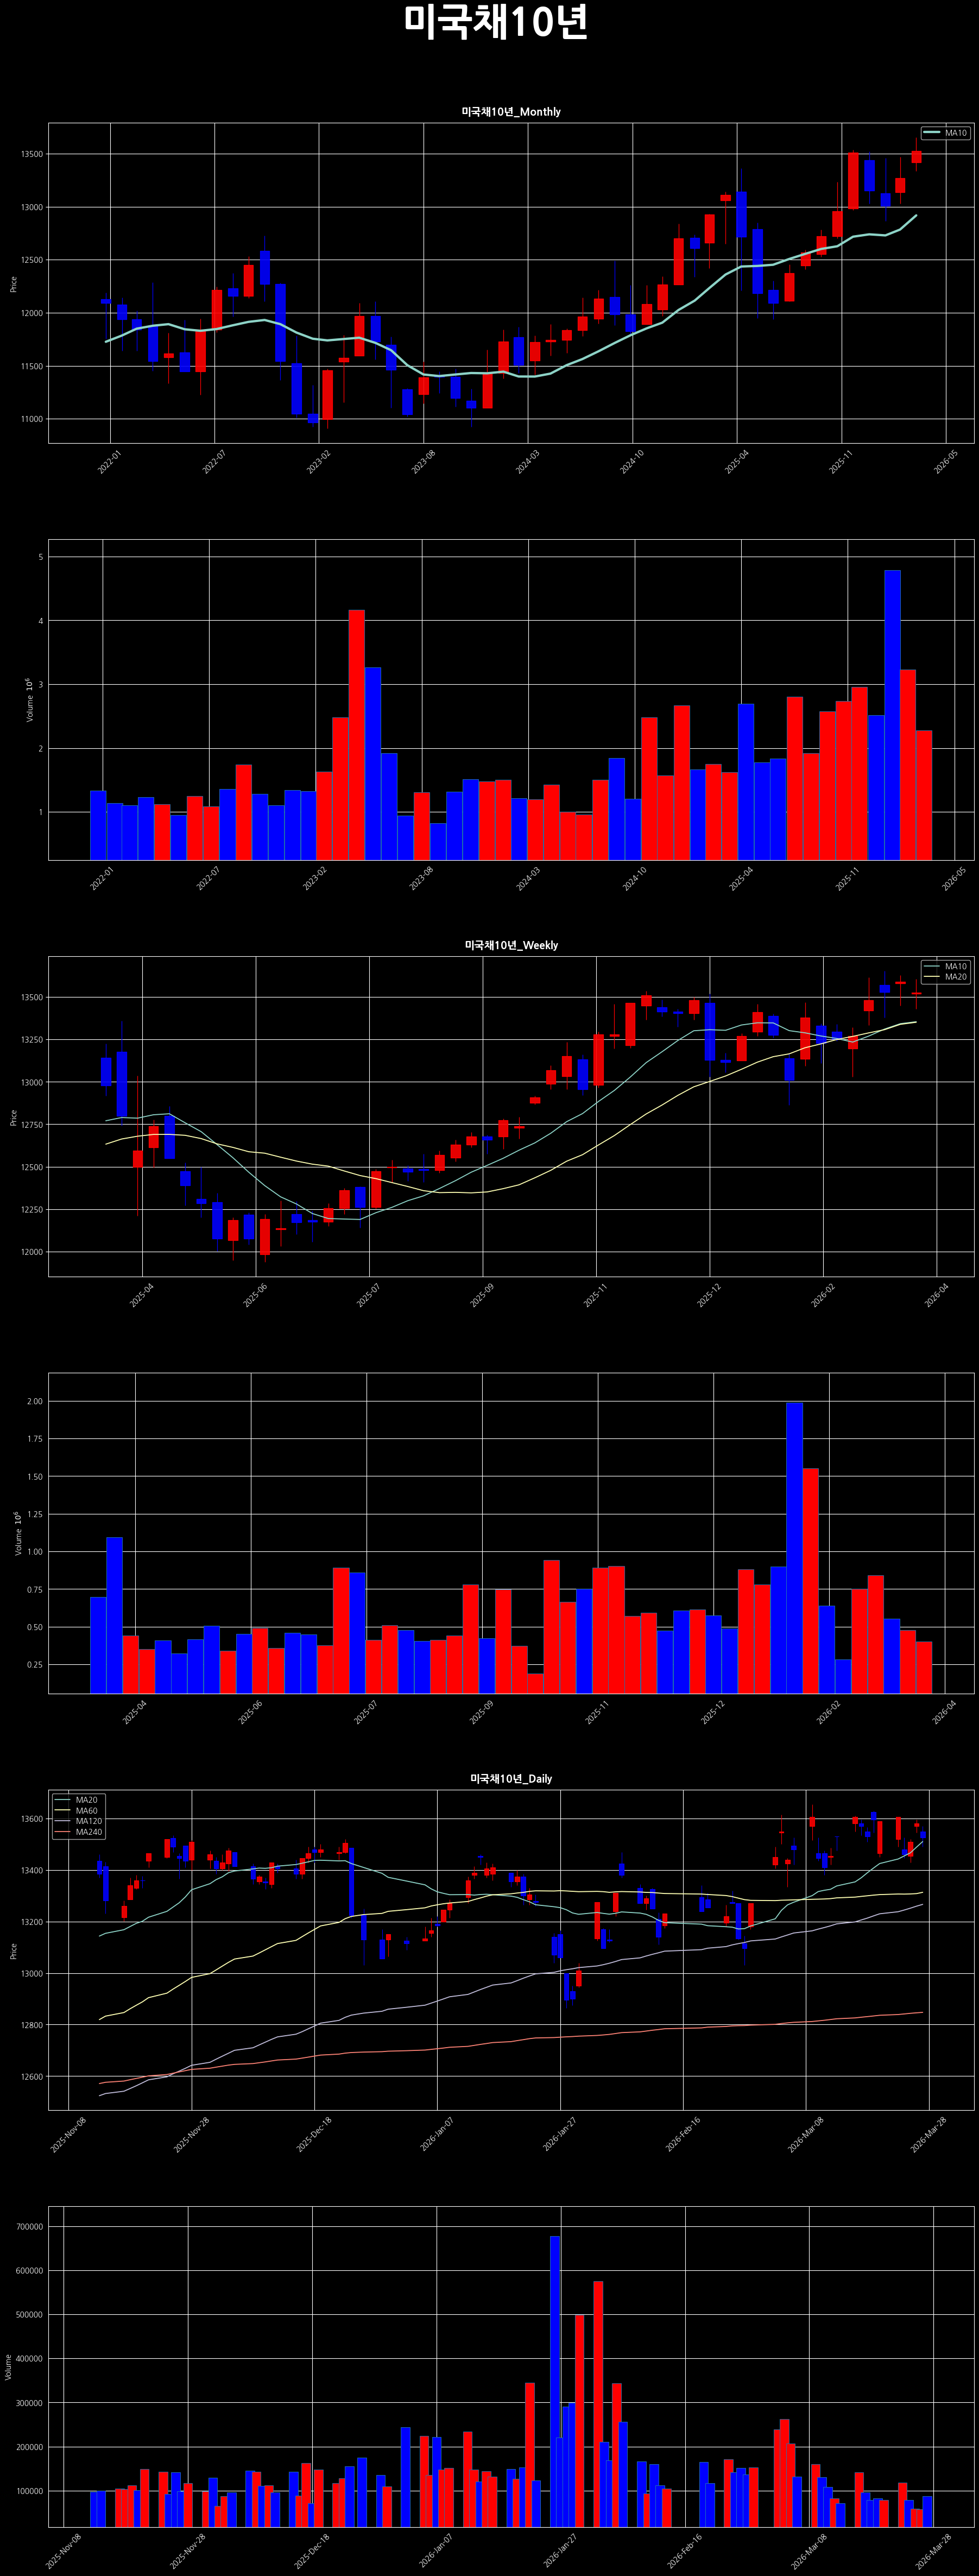

In [11]:
df, df_w, df_m = get_stock_data('305080.KS', period="5y")
draw_chart('미국채10년', df, df_w, df_m)

### 빅테크Top7(손절)

거래량 증가 + 하락 = 가장 나쁜 조합이에요. 큰손들이 적극적으로 던지고 있다는 신호거든요.
특히 거래량 차트를 보면 2026년 3월 말 현재 블루(매수) 거래량이 크게 튀고 있는데 이게 반등 매수인지 확인이 필요하지만,
동시에 음봉이 나오고 있다면 매수세가 들어와도 가격을 못 올리는 상태 즉 매도 압력이 그만큼 강하다는 뜻이에요.

손절이 맞아 보여요. 이유 세 가지예요.
- 첫째, 거래량 증가하면서 하락은 오늘 본 모든 종목 중 가장 나쁜 신호예요.
- 둘째, 인플레이션 뷰를 가지고 계신다면 빅테크는 가장 불리한 자산이에요. 본인의 매크로 뷰와 보유 자산이 충돌하고 있는 상태예요.
- 셋째, -5%는 아직 감당 가능한 손실이에요. 월봉 MA10까지 추가 하락하면 훨씬 더 큰 손실이 될 수 있어요.

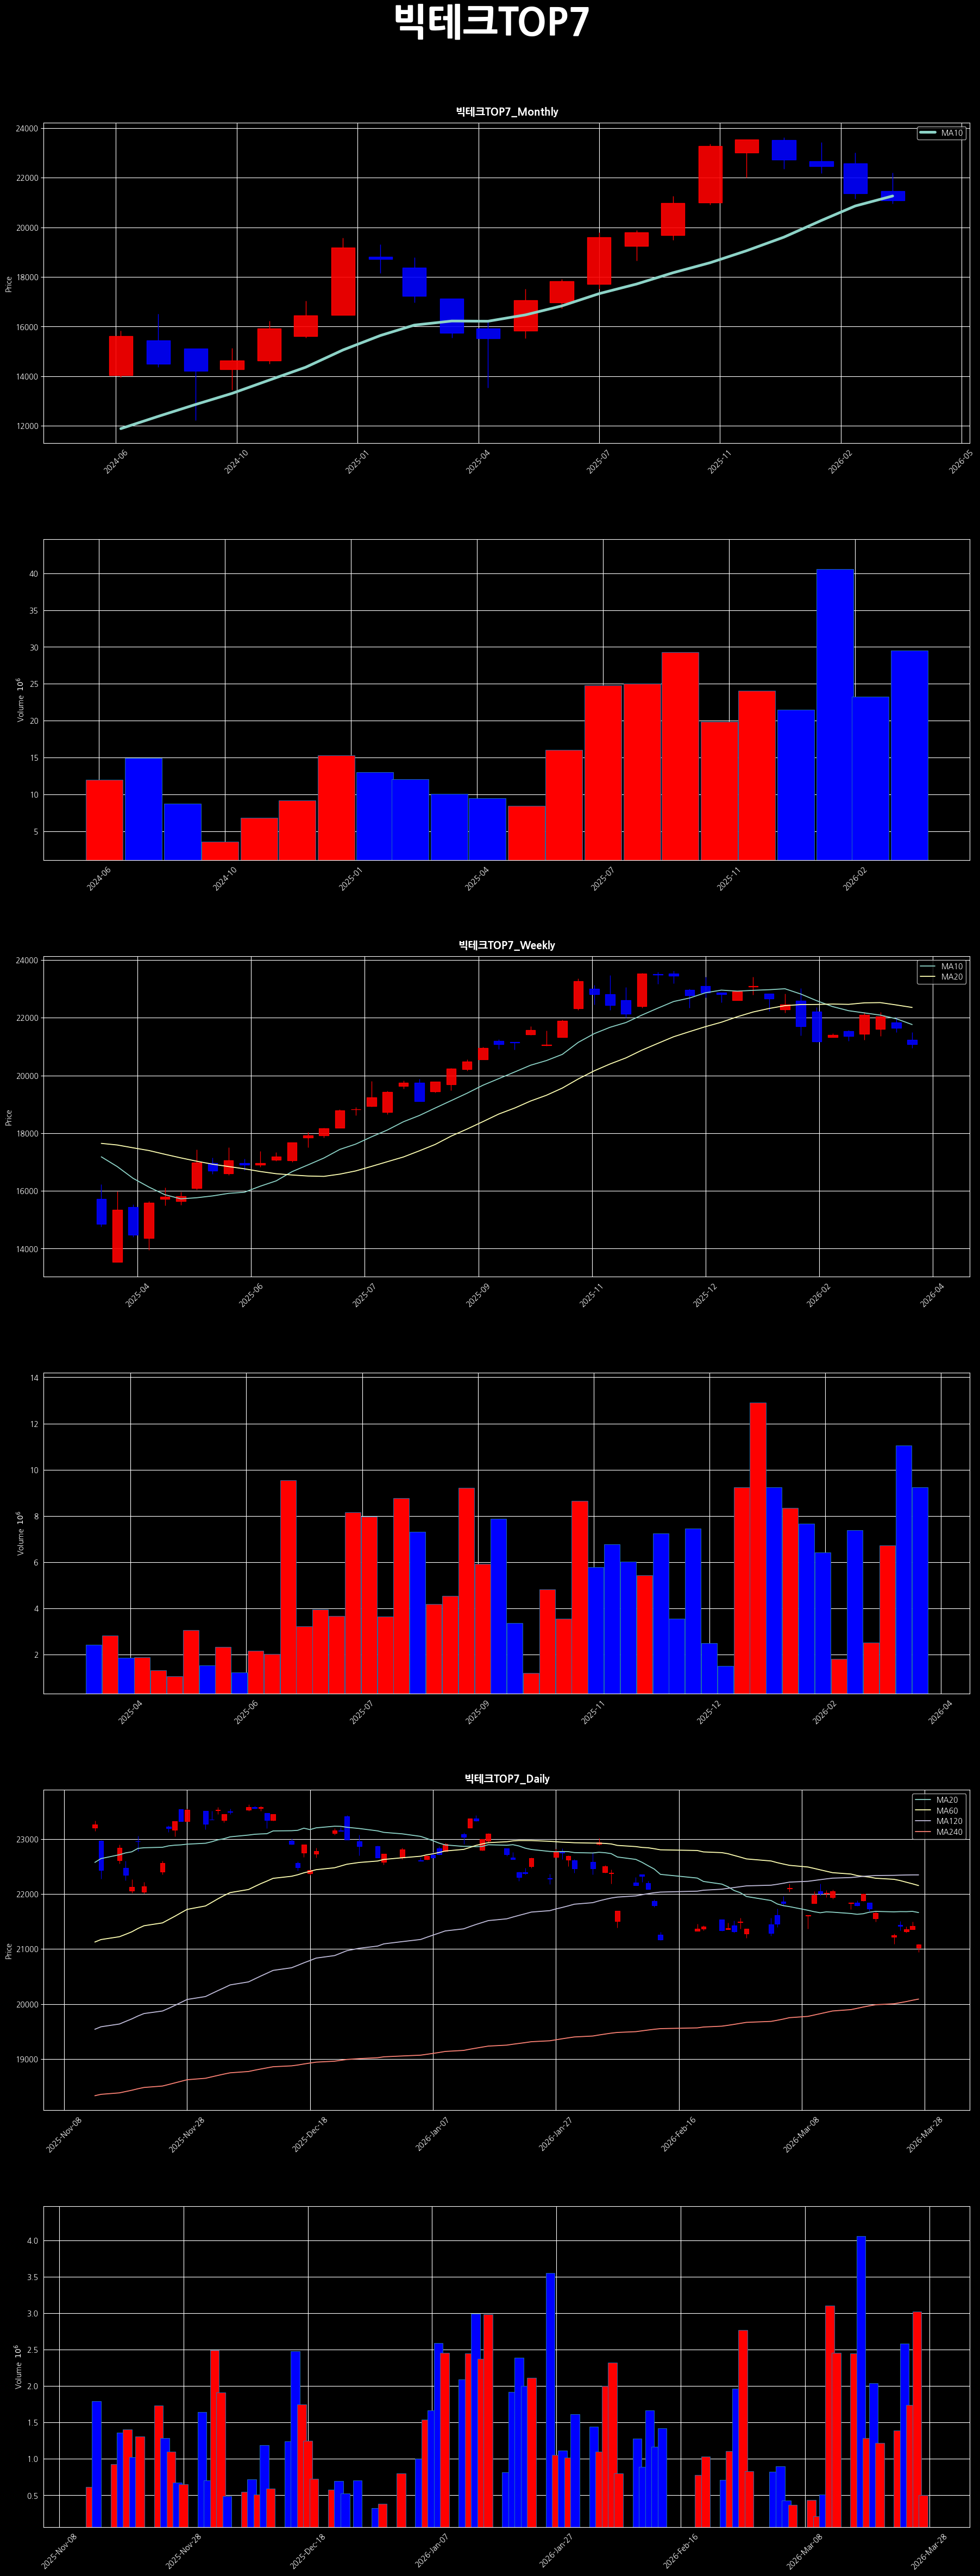

In [12]:
df, df_w, df_m = get_stock_data('465580.KS', period="5y")
draw_chart('빅테크TOP7', df, df_w, df_m)

### 반도체
지켜보는 판단 맞아요. 조건을 달자면
홀딩 유지 조건

- 주봉 MA10이 하향 전환하지 않는 것
- 거래량 증가하면서 음봉이 나오지 않는 것
- 월봉 MA10 위에서 유지되는 것

재검토 필요한 시점
- 주봉 데드크로스 발생 시
- 거래량 급증하면서 하락 시

지금은 빅테크는 매도, 반도체는 홀딩이 가장 일관된 전략으로 보여요

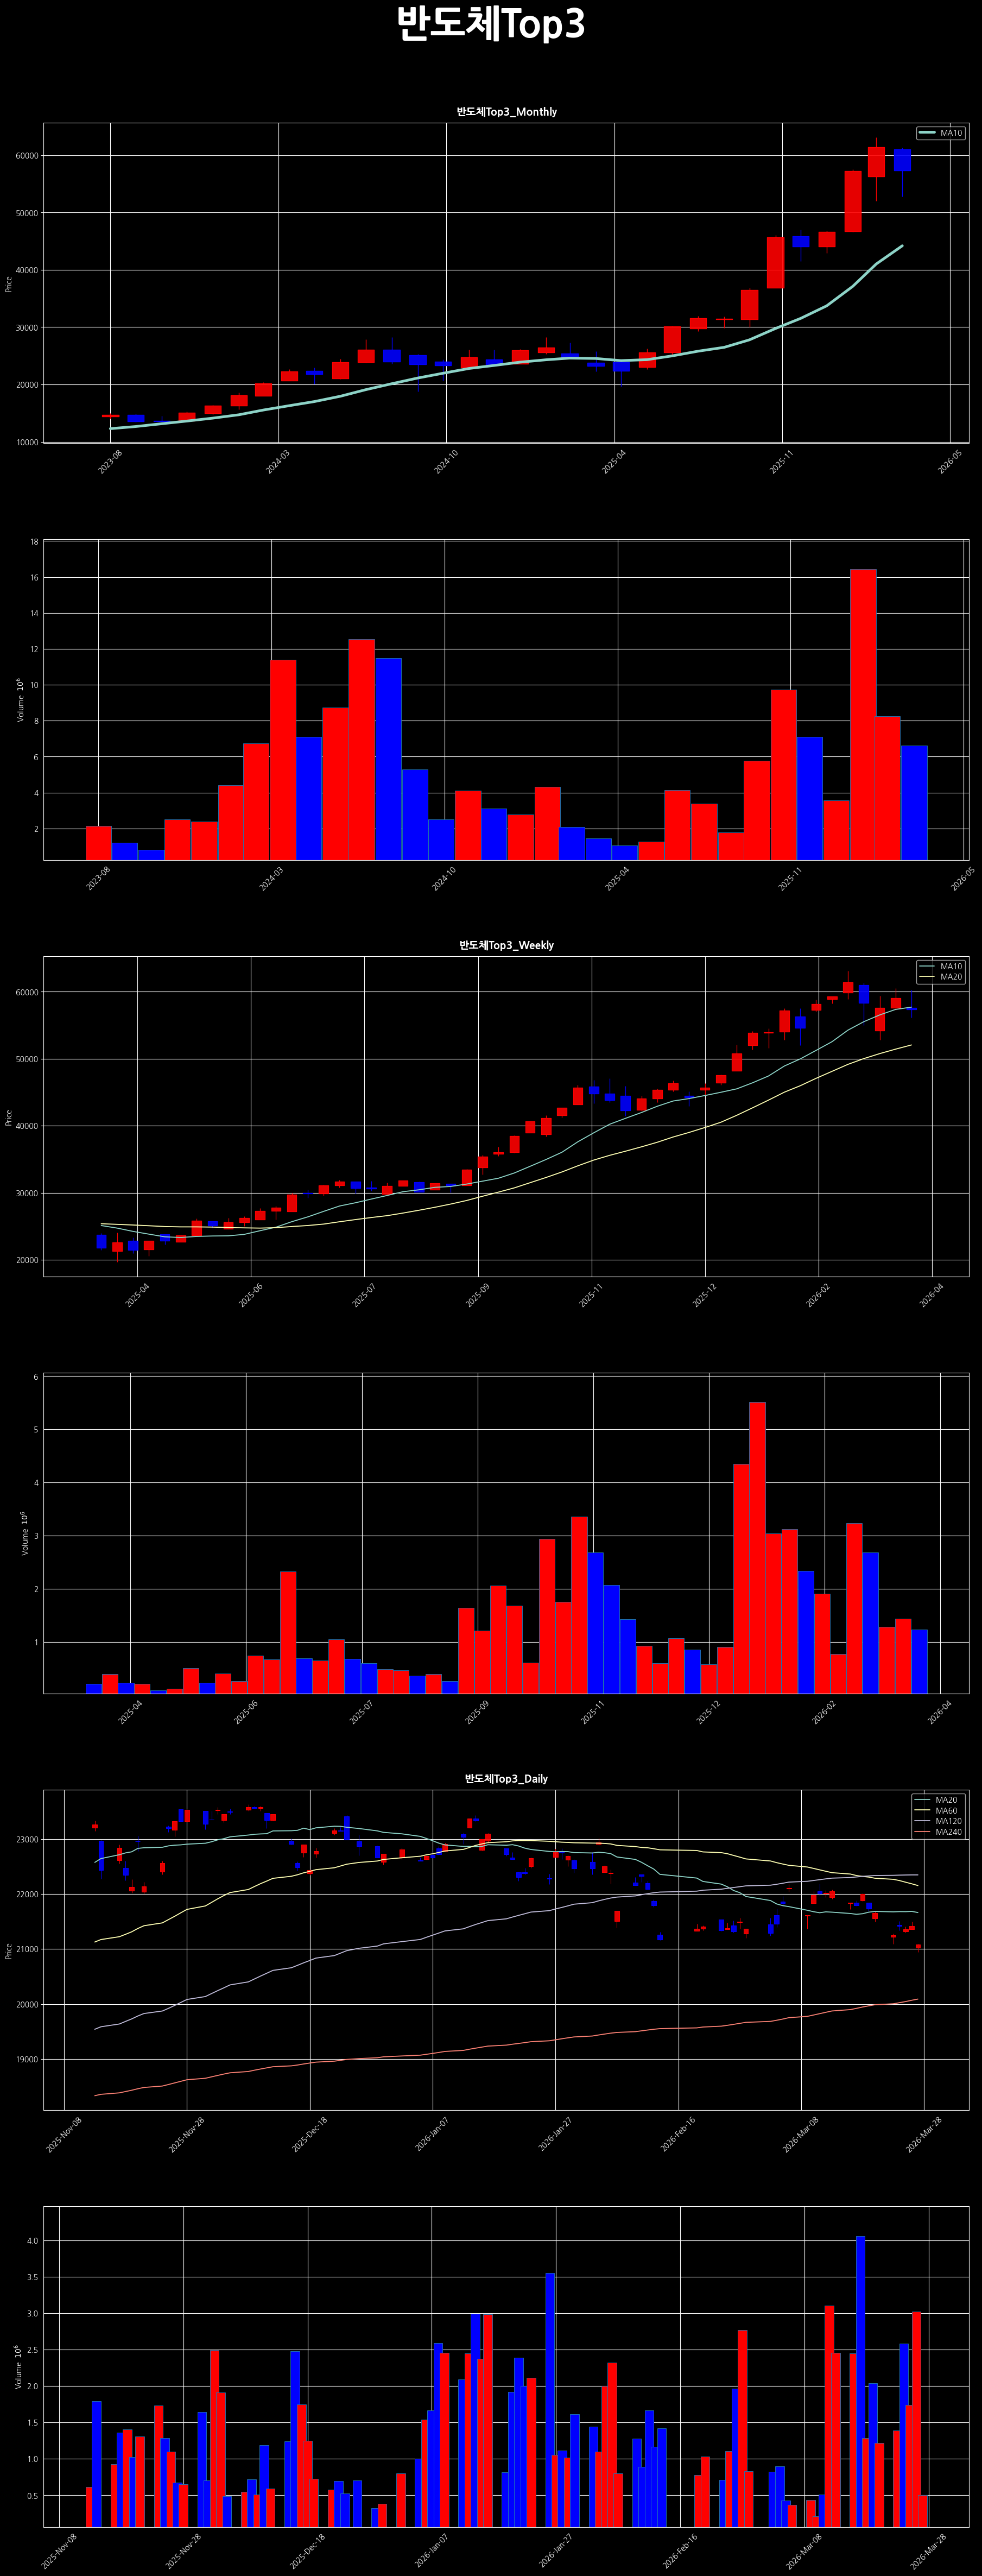

In [13]:
f, df_w, df_m = get_stock_data('446770.KS', period="5y")
draw_chart('반도체Top3', df, df_w, df_m)